Hola **Daniela**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 

# Proyecto 14: Análisis de pérdida de clientes en Gimnasio

## 1. Importar paquetes

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración gráfica
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)



## 2. Cargar datos

Se carga una base de datos de gimnasio con una variable churn que determina si un cliente está activo (1) o no (0) y 13 variables descriptivas para analizar el caso de pérdidas de clientes. No tenemos valores nulos.

In [2]:
gym = pd.read_csv('/datasets/gym_churn_us.csv')
print("Tamaño del dataset:", gym.shape)
gym.head()

Tamaño del dataset: (4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

## 3. Análisis exploratorio de datos (EDA)

### a. Análisis descriptivo

In [4]:
# valores faltantes
gym.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

### b. Análisis de clientes que se fueron y los que se quedaron

En promedio el 26.5% de los clientes han cancelado, lo que representa un problema significativo para el negocio. Los clientes tienen una edad promedio de 29 años y una permanencia promedio de 3.7 meses. La frecuencia promedio de visitas es de aproximadamente 1.8 veces por semana. La mayoría de los clientes viven cerca del gimnasio (84.5%), mientras que el 41% participa en clases grupales. Existe una alta variabilidad en los gastos adicionales, lo que indica diferentes niveles de compromiso económico entre los clientes.

In [5]:
gym.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, analizaste muy bien de manera inicial los datos con lo que trabajarás. Siempre este paso es importante para entender calidad y distribución de las variables
</div>

### c. Histogramas y distribuciones

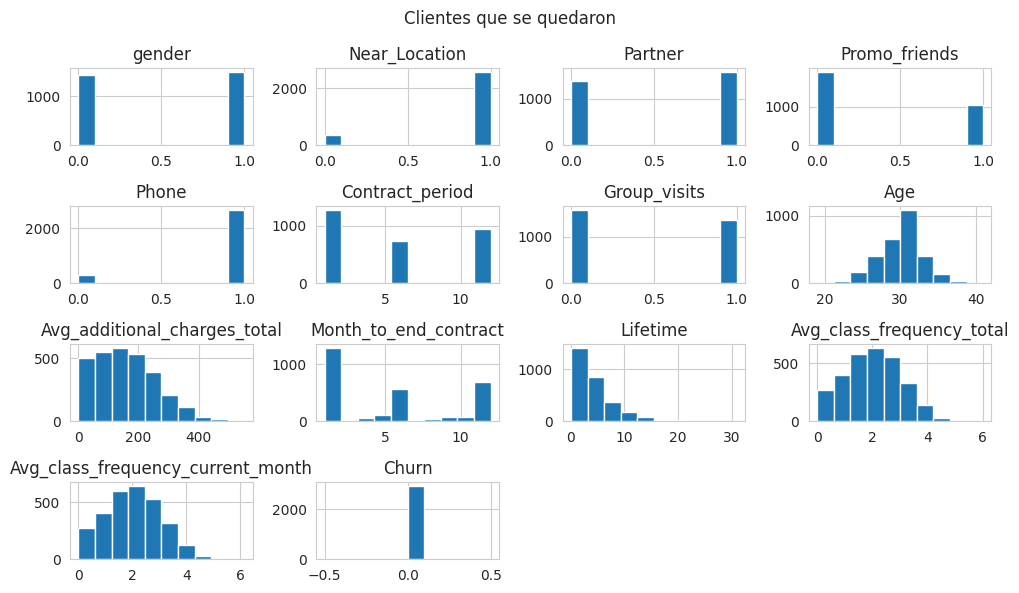

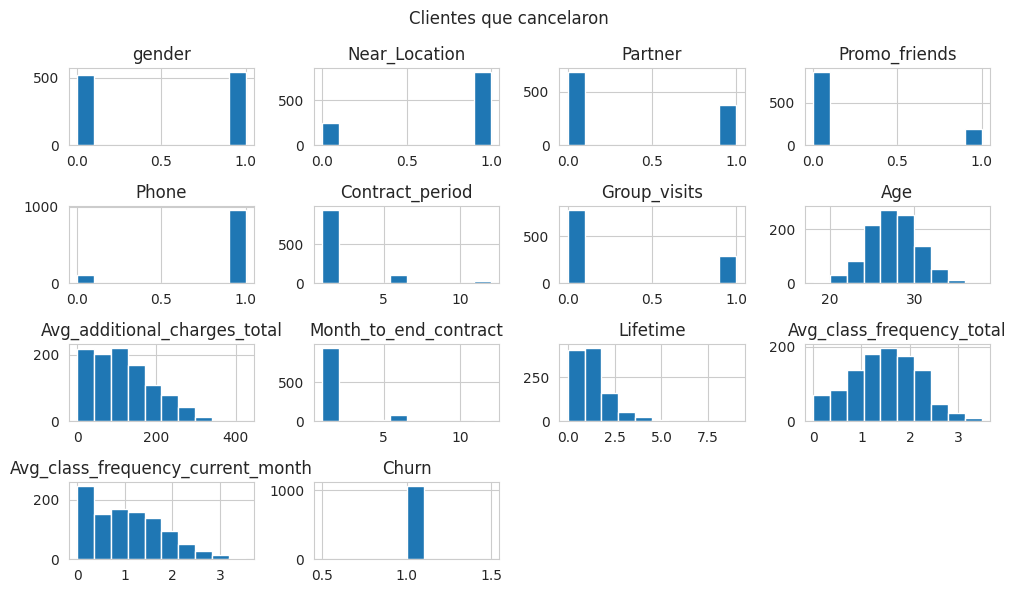

In [6]:
# Separamos los dos grupos
churn_yes = gym[gym['Churn'] == 1]  # cancelaron
churn_no  = gym[gym['Churn'] == 0]  # se quedaron

# Histograma de los que se quedaron
churn_no.hist()
plt.suptitle('Clientes que se quedaron')
plt.tight_layout()
plt.show()

# Histograma de los que cancelaron
churn_yes.hist()
plt.suptitle('Clientes que cancelaron')
plt.tight_layout()
plt.show()

Al comparar las distribuciones entre clientes que cancelaron y los que se quedaron, se identifican varios patrones importantes. Los clientes que cancelaron tienden a tener contratos de corta duración (1 mes), poca antigüedad en el gimnasio (0-2 meses) y una frecuencia de visitas muy baja (0-1 vez por semana). Además, la mayoría no participa en clases grupales. En contraste, los clientes que se quedaron tienen contratos más largos, mayor antigüedad y visitan el gimnasio con más regularidad. Estos patrones sugieren que el compromiso temprano y la participación activa son factores clave para retener clientes.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecho! Estas gráficas son muy claras para mostrar las diferencias entre cada variable de tu dataset
</div>

### d. Matriz de correlación

In [7]:
corr = gym.corr()
corr

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
gender,1.000000,0.006699,-0.010463,-0.005033,-0.008542,0.000502,0.017879,0.013807,-0.009334,-0.001281,0.013579,0.014620,0.009156,0.000708
Near_Location,0.006699,1.000000,-0.005119,0.210964,-0.015763,0.150233,0.154728,0.058358,0.040761,0.143961,0.070921,0.043127,0.062664,-0.128098
Partner,-0.010463,-0.005119,1.000000,0.451960,0.009970,0.306166,0.022710,0.047480,0.022941,0.294632,0.061229,0.024938,0.045561,-0.157986
Promo_friends,-0.005033,0.210964,0.451960,1.000000,0.001982,0.244552,0.120170,0.050113,0.036898,0.239553,0.072721,0.028063,0.053768,-0.162233
Phone,-0.008542,-0.015763,0.009970,0.001982,1.000000,-0.006893,-0.010099,-0.011403,0.009279,-0.011196,-0.018801,0.008340,0.013375,-0.001177
Contract_period,0.000502,0.150233,0.306166,0.244552,-0.006893,1.000000,0.169991,0.138249,0.111445,0.973064,0.170725,0.096211,0.159407,-0.389984
Group_visits,0.017879,0.154728,0.022710,0.120170,-0.010099,0.169991,1.000000,0.080934,0.032079,0.163703,0.075853,0.056695,0.075923,-0.175325
Age,0.013807,0.058358,0.047480,0.050113,-0.011403,0.138249,0.080934,1.000000,0.080240,0.134511,0.164693,0.119953,0.183095,-0.404735
Avg_additional_charges_total,-0.009334,0.040761,0.022941,0.036898,0.009279,0.111445,0.032079,0.080240,1.000000,0.113958,0.079028,0.044426,0.079570,-0.198697
Month_to_end_contract,-0.001281,0.143961,0.294632,0.239553,-0.011196,0.973064,0.163703,0.134511,0.113958,1.000000,0.161078,0.085387,0.147605,-0.381393


La matriz de correlación muestra que las variables con mayor relación con la cancelación son la antigüedad del cliente (Lifetime: -0.44), la edad (Age: -0.40), la frecuencia de visitas del mes actual (Avg_class_frequency_current_month: -0.41) y el período de contrato (Contract_period: -0.39). Todas estas correlaciones son negativas, lo que significa que a mayor valor en estas variables, menor probabilidad de cancelación. Por el contrario, el género y el teléfono registrado tienen correlaciones cercanas a cero, por lo que no parecen ser factores relevantes para predecir la cancelación.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien mostrada la matriz de correlación! Solo ten en cuenta que no siempre correlación significa causalidad, puede que en algunos casos tengas variables altamente correlacionadas pero no necesariamente son causa una de la otra

## 3. Construcción de modelo de prediccón

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [9]:
y = gym['Churn']
X = gym.drop(['Churn'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [10]:
model_lr = LogisticRegression(random_state=0, max_iter=1000)
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)

print('Regresión Logística:')
print('Exactitud:', accuracy_score(y_test, pred_lr))
print('Precisión:', precision_score(y_test, pred_lr))
print('Recall:', recall_score(y_test, pred_lr))

Regresión Logística:
Exactitud: 0.92375
Precisión: 0.8586387434554974
Recall: 0.8282828282828283


In [11]:
model_rf = RandomForestClassifier(random_state=0)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

print('Random Forest:')
print('Exactitud:', accuracy_score(y_test, pred_rf))
print('Precisión:', precision_score(y_test, pred_rf))
print('Recall:', recall_score(y_test, pred_rf))

Random Forest:
Exactitud: 0.91625
Precisión: 0.8393782383419689
Recall: 0.8181818181818182


Ambos modelos muestran un buen desempeño para predecir la cancelación de clientes. La Regresión Logística obtuvo mejores resultados en las tres métricas: exactitud (92.4%), precisión (85.9%) y recall (82.8%), superando al Bosque Aleatorio en todos los casos. La precisión indica que cuando el modelo predice que un cliente va a cancelar, acierta el 85.9% de las veces. El recall indica que el modelo es capaz de detectar el 82.8% de los clientes que realmente cancelarán, lo cual es especialmente valioso para el negocio ya que permite identificar a tiempo a los clientes en riesgo y tomar acciones de retención.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo! Obtuviste resultados muy buenos en el entrenamiento de tus modelos y realizaste el análisis adecuado a partir de los mismos
</div>

## 4. Clústeres de usuarios 

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [13]:
# Quitamos la columna Churn porque el clustering no la necesita
X_cluster = gym.drop('Churn', axis=1)

# Estandarizamos para que todas las variables tengan la misma escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

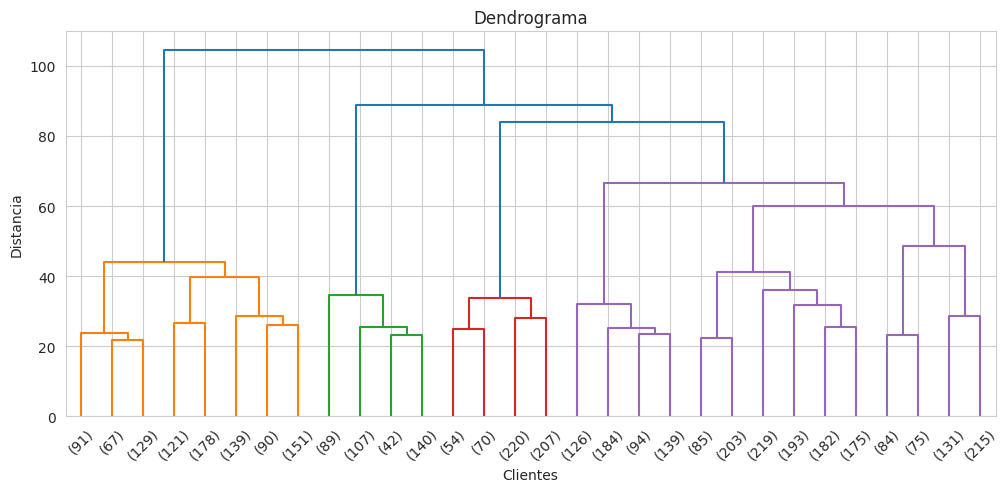

In [14]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title('Dendrograma')
plt.xlabel('Clientes')
plt.ylabel('Distancia')
plt.show()

El dendrograma muestra cómo los clientes se agrupan según sus similitudes. Los saltos más grandes en la parte superior del gráfico (distancias entre 85 y 105) indican que existen grupos bien diferenciados entre sí. El gráfico revela 5 grupos naturales representados por los colores naranja, verde, rojo, azul y morado, lo que confirma que usar 5 clústeres es una elección adecuada para este análisis.

## Valores medios de clusteres

In [15]:
kmeans = KMeans(n_clusters=5, random_state=0)
gym['Cluster'] = kmeans.fit_predict(X_scaled)

In [16]:
gym.groupby('Cluster').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
Cluster,,,,,,,,,,,,,,
0,0.502970,0.959406,0.783168,0.574257,1.000000,10.889109,0.542574,29.982178,160.761016,9.954455,4.736634,1.982055,1.974789,0.027723
1,0.522078,0.862338,0.470130,0.306494,0.000000,4.787013,0.425974,29.301299,143.957664,4.475325,3.924675,1.847220,1.716369,0.267532
2,0.495050,0.000000,0.463366,0.079208,1.000000,2.352475,0.215842,28.477228,135.457501,2.198020,2.809901,1.660461,1.477324,0.443564
3,0.485737,1.000000,0.350238,0.240095,1.000000,1.948494,0.341521,28.167987,131.622204,1.856577,2.440571,1.247634,1.012983,0.514263
4,0.559666,0.976134,0.356802,0.230310,0.998807,2.669451,0.473747,30.125298,161.657905,2.459427,4.898568,2.852002,2.850161,0.068019


El análisis de los valores medios por clúster revela patrones claros de comportamiento. Los clústeres 0 y 4 son los más leales con tasas de cancelación de apenas 2.8% y 6.8% respectivamente, caracterizados por contratos largos y alta frecuencia de visitas. En el extremo opuesto, los clústeres 2 y 3 son los más propensos a cancelar con tasas de 44.4% y 51.4%, tienen contratos muy cortos y visitan el gimnasio con poca frecuencia. El clúster 1 representa un grupo de riesgo medio con una tasa de cancelación del 26.8%. Esto confirma que la duración del contrato y la frecuencia de visitas son los factores más determinantes para la retención de clientes.

## Distribuciones de características

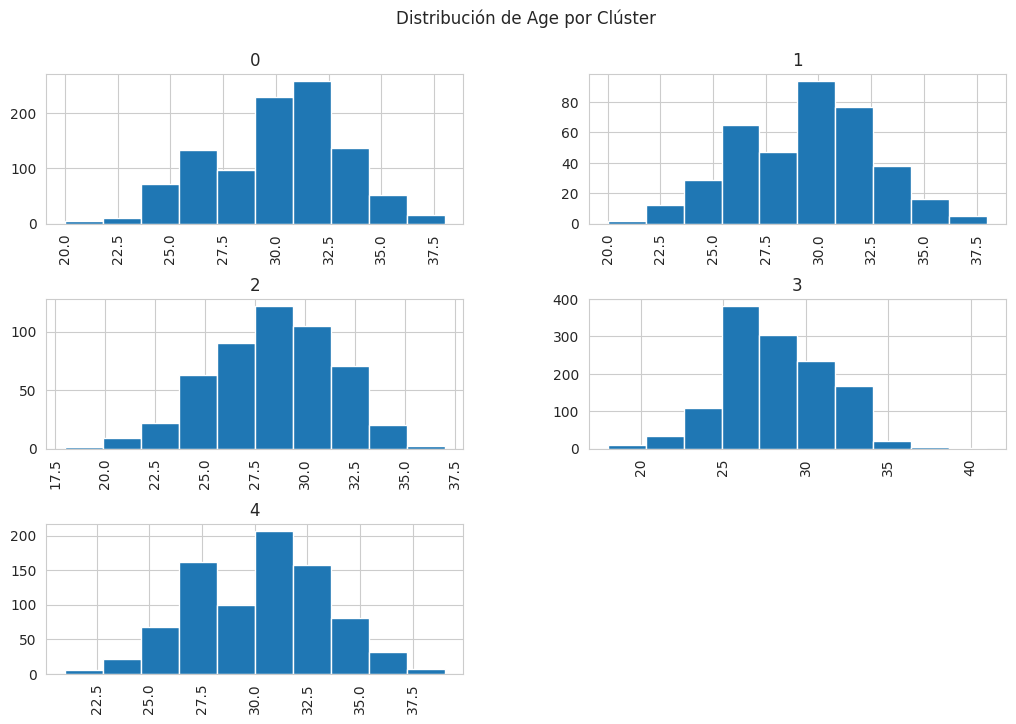

In [17]:
gym.hist(column='Age', by='Cluster', figsize=(12, 8))
plt.suptitle('Distribución de Age por Clúster')
plt.show()

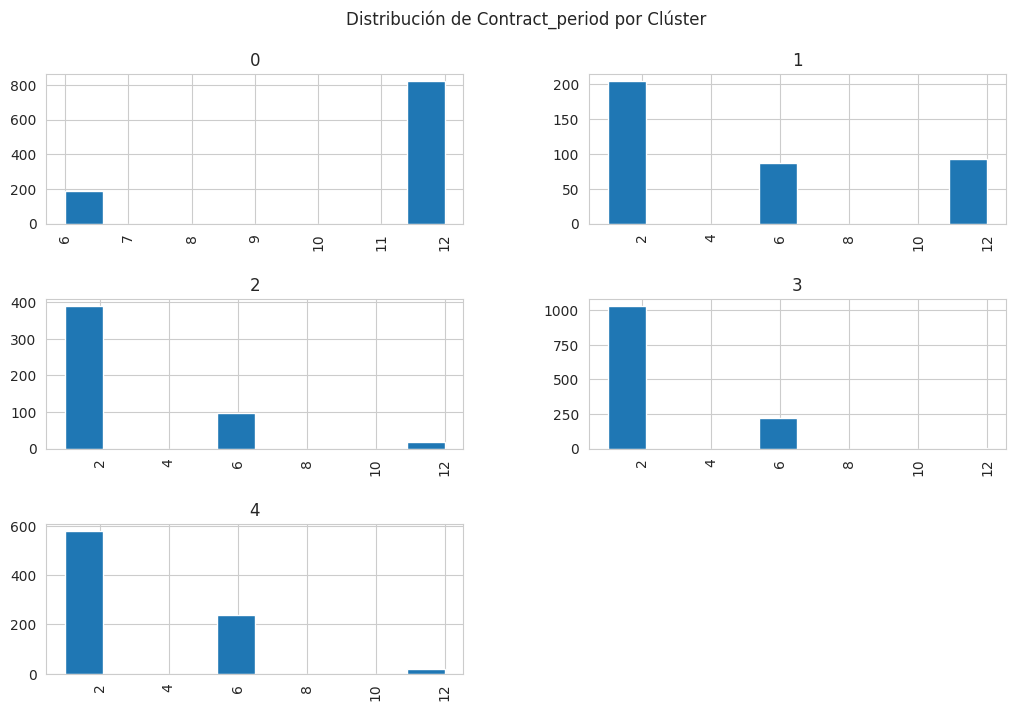

In [18]:
gym.hist(column='Contract_period', by='Cluster', figsize=(12, 8))
plt.suptitle('Distribución de Contract_period por Clúster')
plt.show()

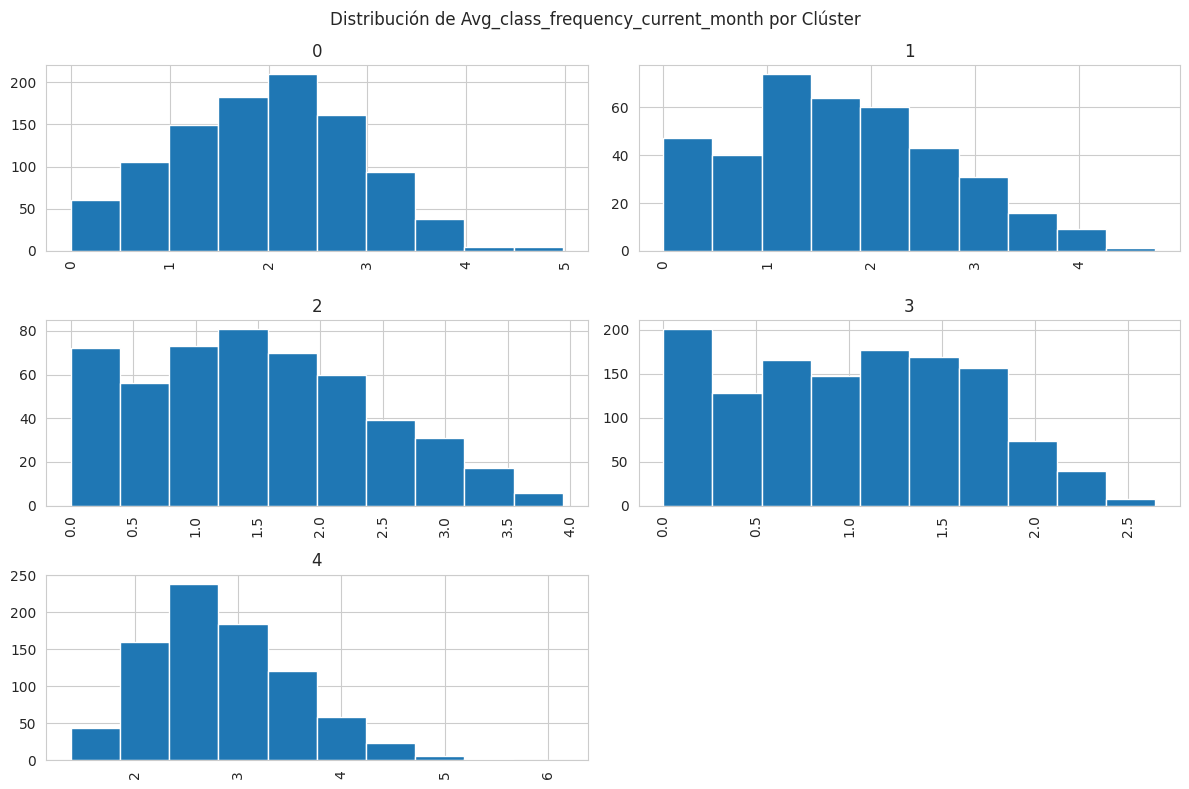

In [19]:
gym.hist(column='Avg_class_frequency_current_month', by='Cluster', figsize=(12, 8))
plt.suptitle('Distribución de Avg_class_frequency_current_month por Clúster')
plt.tight_layout()
plt.show()

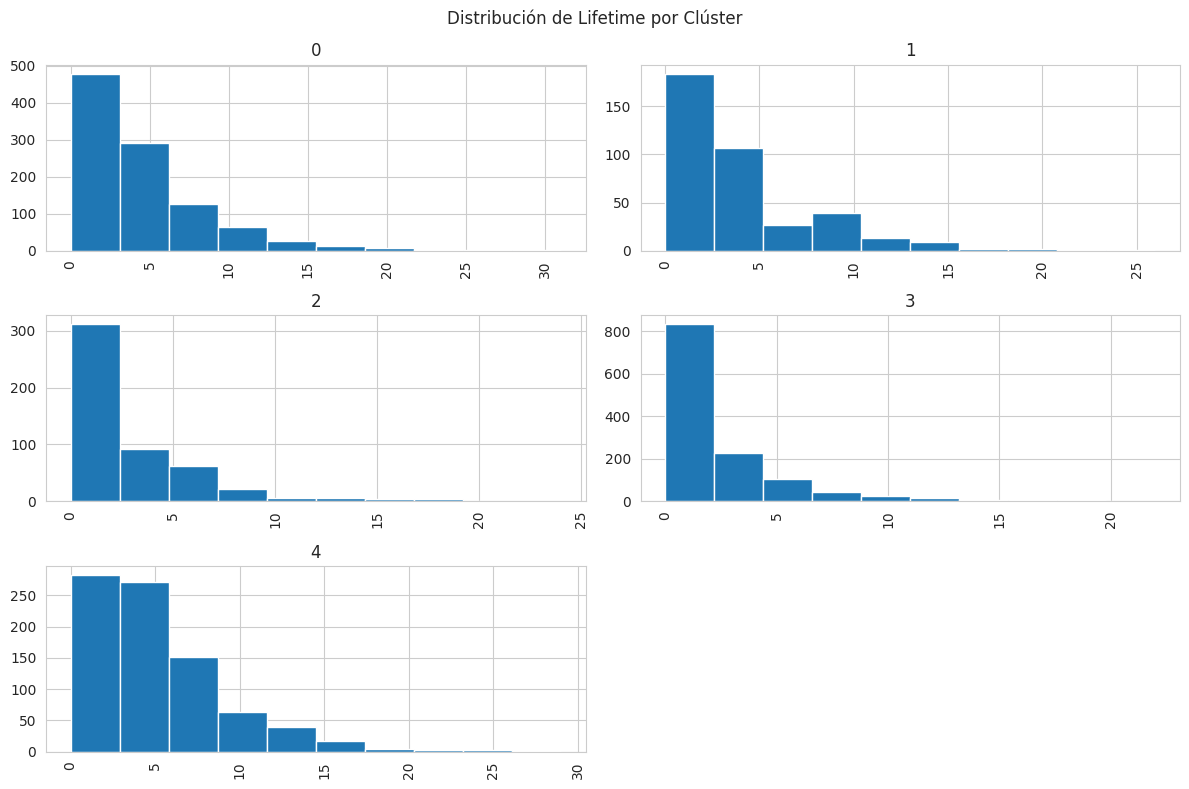

In [20]:
gym.hist(column='Lifetime', by='Cluster', figsize=(12, 8))
plt.suptitle('Distribución de Lifetime por Clúster')
plt.tight_layout()
plt.show()

Las distribuciones revelan patrones consistentes entre los clústeres. En cuanto a la edad, todos los grupos se concentran entre 25 y 35 años, sin diferencias significativas entre ellos. Respecto al período de contrato, el clúster 0 predomina en contratos de 12 meses, mientras que los clústeres 2, 3 y 4 se concentran en contratos de 1-2 meses, lo que los hace más vulnerables a la cancelación. En la frecuencia de visitas, el clúster 4 es el más activo (2-4 visitas/semana), mientras que los clústeres 2 y 3 visitan con menor regularidad. Finalmente, en antigüedad, todos los clústeres tienen mayormente clientes nuevos (0-5 meses), pero el clúster 0 es el único que retiene clientes por más tiempo.

## Tasa de cancelación

In [21]:
churn_by_cluster = gym.groupby('Cluster')['Churn'].mean().round(3) * 100
print(churn_by_cluster)

Cluster
0     2.8
1    26.8
2    44.4
3    51.4
4     6.8
Name: Churn, dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Bien hecho! Se nota claramente la segmentación entre los diferentes grupos ya que tienen un churn rate diferente
</div>

La tasa de cancelación varía significativamente entre clústeres. Los clústeres 0 y 4 son los más leales, con tasas de apenas 2.8% y 6.8% respectivamente, caracterizados por contratos largos y alta frecuencia de visitas. El clúster 1 representa un grupo de riesgo medio con 26.8% de cancelación. En el extremo opuesto, los clústeres 2 y 3 son los más propensos a cancelar con tasas de 44.4% y 51.4%, concentrando clientes nuevos con contratos cortos y baja frecuencia de visitas. Esto confirma que la duración del contrato y el nivel de actividad son los factores más determinantes para la retención.

# 5. Conclusiones y recomendaciones

1. Los clientes con contratos de 6 o 12 meses cancelan mucho menos que los de 1-2 meses. Se recomienda ofrecer descuentos o beneficios exclusivos al momento de la inscripción para motivar la contratación de planes anuales.
   - Recomendación: Incentivar contratos de larga duración desde el inicio
2. La mayoría de las cancelaciones ocurren en clientes con menos de 5 meses de antigüedad. El gimnasio debería implementar un programa de bienvenida: seguimiento personalizado, metas de progreso y recordatorios de visita durante los primeros 3 meses.
   - Recomendación: Aumentar el compromiso en los primeros meses
3. Los clientes que asisten a clases grupales muestran mayor frecuencia de visitas y menor tasa de cancelación. Se recomienda ofrecer una clase grupal gratuita al momento de la inscripción para generar el hábito desde el inicio.
   - Recomendación: Fomentar la participación en clases grupales
4. Los clústeres 2 y 3 (cancelación superior al 44%) pueden detectarse con el modelo predictivo desarrollado. Con esta información, el gimnasio puede contactar proactivamente a estos clientes con ofertas personalizadas o descuentos de renovación antes de que cancelen.
   - Recomendación: Identificar y actuar sobre clientes en riesgo

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo, manejaste muy bien los datos previo al entrenamiento de tus modelos y analizaste muy bien los resultados.
    
Planteaste muy buenas conclusiones en base a los datos de tu análisis, un buen análisis siempre debe venir acompañado de recomendaciones que ayuden a la toma de decisiones que en este caso haz planteado sugerencias muy buenas en cuanto a los diferentes tipos de usuarios obtenidos.
    
    
Saludos!
</div>